## Import Libs

In [1]:

# Import libraries
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

# sns.set_style('darkgrid')

from pathlib import Path
# research_path = Path('../') # 'utils_functionality/')

import os
import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc

from tqdm.notebook import tqdm

beta here denotes exponent in the drag coefficient correction

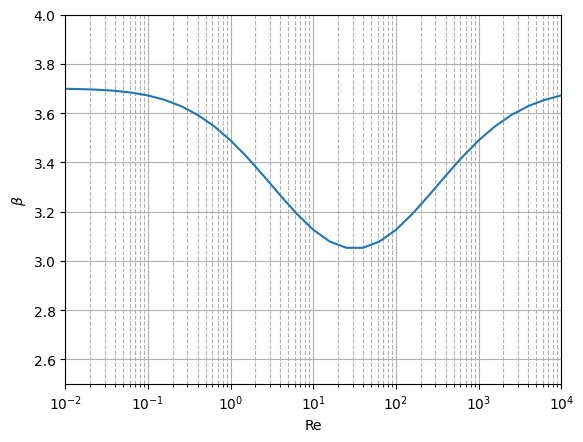

In [2]:
power = np.arange(-2, 5, step=0.2)
Re_vec = 10**power

beta = lambda Re: 3.7 - 0.65*np.exp(
        -0.5 * (1.5 - np.log10(Re))**2
    )

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=beta(Re_vec),
    ax=ax,
)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(1*10**-2, 10**4)
ax.set_ylim(2.5, 4)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel(r'$\beta$');

Compare with source plot [DiFelice1994VoidageFunction]:

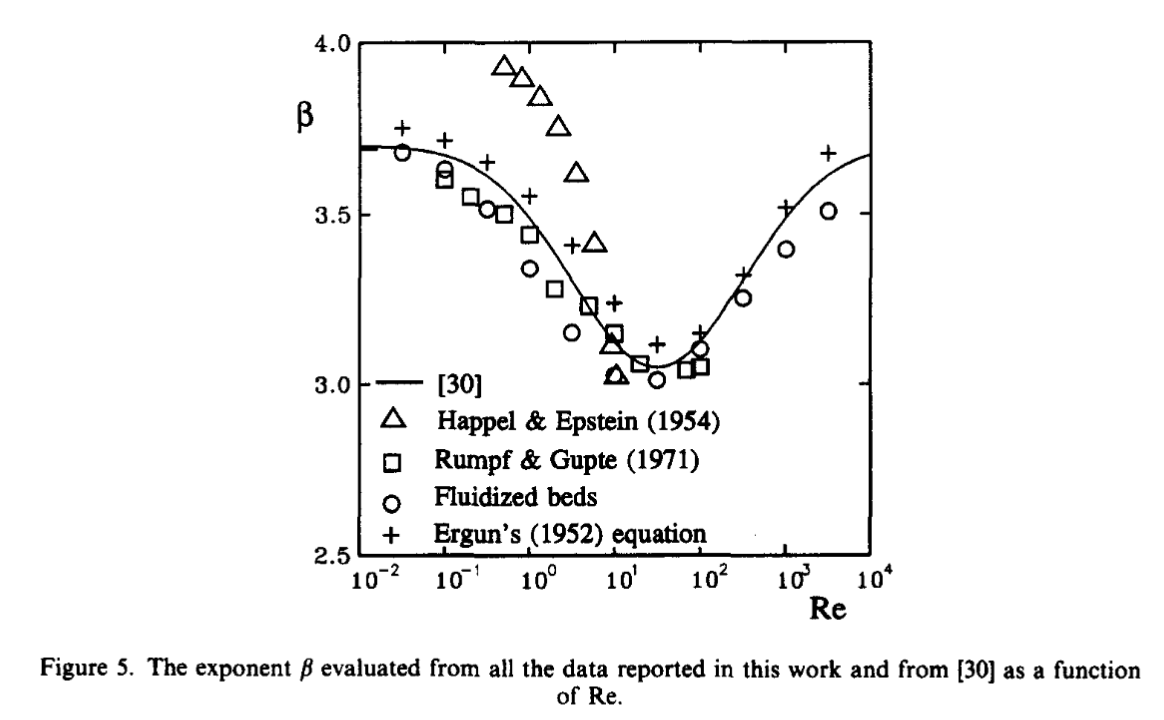

## Drag coefficient plot vs sedimentation drag coefficient plot

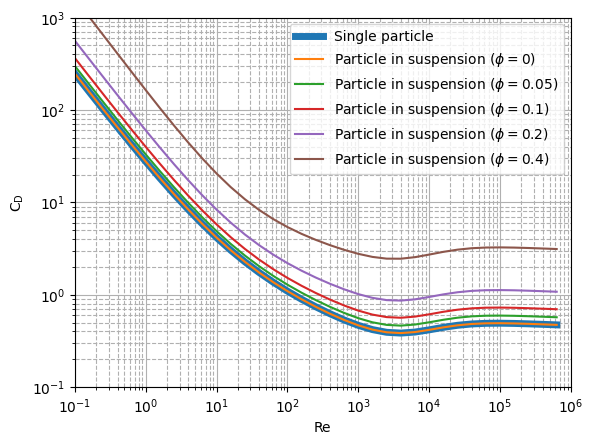

In [3]:
power = np.arange(-2, 6, step=0.2)
Re_vec = 10**power

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
    label='Single particle',
    linewidth=5,
)

phi = 0
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.05
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.10
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.20
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.40
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1*10**-1, 10**6)
ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$')
ax.legend();

## Test Sedimentation System

Consider Oz oriented down.

SMALL GRID

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 1001
N_E = 1001
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 2)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
z_p [m] = [0.00e+00 1.00e-05 2.00e-05 ... 9.98e-03 9.99e-03 1.00e-02]
v_p [m/s] = [0. 0. 0. ... 0. 0. 0.]
phi = [0.1 0.1 0.1 ... 0.1 0.1 0.1]
q_phi [1/s] = [0. 0. 0. ... 0. 0. 0.]

LAST, t= 2.0 s
z_p [m] = [5.61210000e-05 6.61210000e-05 7.61210000e-05 ... 1.00351843e-02
 1.00460657e-02 1.00561210e-02]
v_p [m/s] = [2.80605857e-05 2.80605857e-05 2.80605857e-05 ... 2.80605857e-05
 2.80605857e-05 2.80605857e-05]
phi = [0.1        0.1        0.1        ... 0.12208112 0.63853768 0.1       ]
q_phi [1/s] = [ 0.00000000e+00  2.20873747e-20 -2.97671094e-21 ...  3.62947304e-02
  5.23293536e-01  0.00000000e+00]


Измельчение сетки не приводит к плавному распределению частиц. Они также скапливаются в предпоследнем узле

In [12]:
phi_last.shape

(1001,)

In [10]:
phi_last[-15:]

array([0.1       , 0.1       , 0.1       , 0.1       , 0.1       ,
       0.1       , 0.1       , 0.1       , 0.1       , 0.10000007,
       0.10000837, 0.10058105, 0.12208112, 0.63853768, 0.1       ])

In [11]:
q_phi_last[-15:]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.51013459e-14, 1.47713295e-11,
       2.86913627e-09, 3.87630219e-07, 3.31848953e-05, 1.58815865e-03,
       3.62947304e-02, 5.23293536e-01, 0.00000000e+00])

In [9]:
z_p_last[-15:]

array([0.00991612, 0.00992612, 0.00993612, 0.00994612, 0.00995612,
       0.00996612, 0.00997596, 0.00998358, 0.00998695, 0.00998965,
       0.00999979, 0.0100219 , 0.01003518, 0.01004607, 0.01005612])

In [8]:
v_p_last[-15:]

array([2.80605857e-05, 2.80605857e-05, 2.80605856e-05, 2.80605804e-05,
       2.80599914e-05, 2.80192372e-05, 2.65458297e-05, 1.06787520e-05,
       3.66405475e-06, 2.20525954e-05, 2.67651327e-05, 2.80605857e-05,
       2.80605857e-05, 2.80605857e-05, 2.80605857e-05])

In [43]:
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.3e' % x)

# def get_substates(state, verbose=False, display_cnt=None):
#         """Get sub states of the state: particles position, their velocity, particle concentration, particle concentration change rate

#         Args:
#             state: full state
#             verbose: Print substates. Defaults to False.

#         Returns:
#             sub states of the state [z_p, v_p, phi, q_phi]
#         """
        
#         z_p = state[:N_L]
#         v_p = state[N_L:2*N_L]
#         phi = state[2*N_L:2*N_L+N_E]
#         q_phi = state[2*N_L+N_E:2*N_L+2*N_E]
        
#         if verbose:
#             if (display_cnt is None):   
#                 print(f'z_p [m] = {z_p}')
#                 print(f'v_p [m/s] = {v_p}')
#                 print(f'phi = {phi}')
#                 print(f'q_phi [1/s] = {q_phi}')
#             else:
#                 print(f'z_p [m] = {z_p[-display_cnt:]}')
#                 print(f'v_p [m/s] = {v_p[-display_cnt:]}')
#                 print(f'phi = {phi[-display_cnt:]}')
#                 print(f'q_phi [1/s] = {q_phi[-display_cnt:]}')
        
#         return z_p, v_p, phi, q_phi

index_t = 600
t = numerical_results.t[index_t]
print(f'INTERIM, t= {t} s')
z_p, v_p, phi, q_phi = system.get_substates(
    numerical_results.y[:,index_t], verbose=False
)
df = pd.DataFrame(
    {
        'z_p [m]': z_p,
        'v_p [m/s]': v_p,
        'phi': phi,
        'q_phi [1/s]': q_phi
    }
)

display(df.tail(15))

INTERIM, t= 1.2012012012012012 s


,z_p [m],v_p [m/s],phi,q_phi [1/s]
986,9.894e-03,2.806e-05,1.000e-01,0.000e+00
987,9.904e-03,2.806e-05,1.000e-01,0.000e+00
988,9.914e-03,2.806e-05,1.000e-01,0.000e+00
989,9.924e-03,2.806e-05,1.000e-01,0.000e+00
990,9.934e-03,2.806e-05,1.000e-01,0.000e+00
991,9.944e-03,2.806e-05,1.000e-01,0.000e+00
992,9.954e-03,2.806e-05,1.000e-01,0.000e+00
993,9.964e-03,2.806e-05,1.000e-01,1.684e-14
994,9.974e-03,2.790e-05,1.000e-01,1.039e-11
995,9.983e-03,2.116e-05,1.000e-01,4.137e-09


In [46]:
def get_all_substates(states):
        """Get sub states of the state: particles position, their velocity, particle concentration, particle concentration change rate

        Args:
            state: full state

        Returns:
            sub states of the state [z_p, v_p, phi, q_phi]
        """
        
        z_p = states[:N_L,:]
        v_p = states[N_L:2*N_L,:]
        phi = states[2*N_L:2*N_L+N_E,:]
        q_phi = states[2*N_L+N_E:2*N_L+2*N_E,:]
        
        return z_p, v_p, phi, q_phi

z_p, v_p, phi, q_phi = get_all_substates(numerical_results.y)
time = numerical_results.t

Check concentration

In [95]:
y.shape

(5, 10)

In [97]:
y = 1*np.ones(5)
x = np.arange(0, 5)



4.0

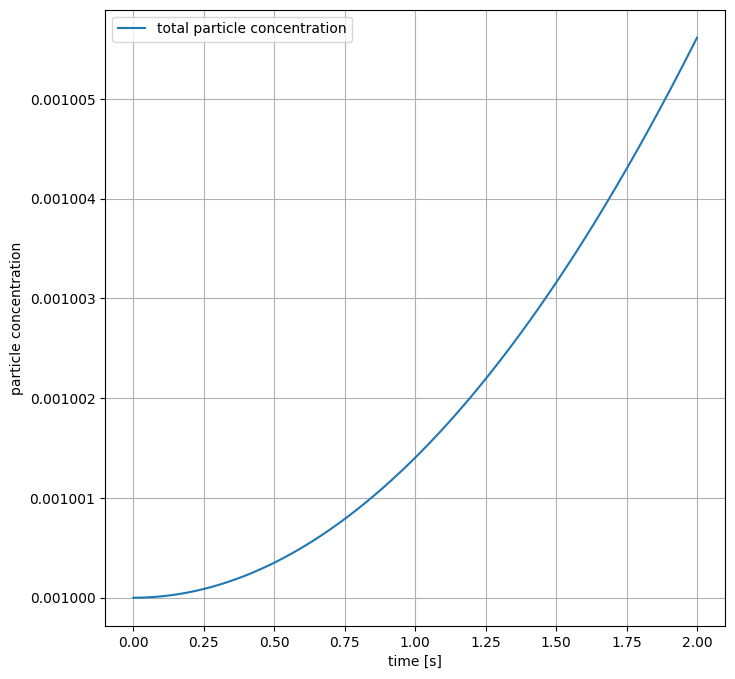

In [99]:
z_nodes = np.linspace(0, h_exit, N_E)

def integrate_phi(z_nodes, phi):
    integrals = np.trapz(
        phi,
        z_nodes,
        axis=0
    )
    
    return integrals

phi_integrals = integrate_phi(
    z_nodes=z_nodes,
    phi=phi
)


fig, ax = plt.subplots(1,1, figsize=(8,8))

ax.plot(
    time,
    phi_integrals,
    label=f'total particle concentration'
)

ax.set_xlabel('time [s]')
ax.set_ylabel('particle concentration')
ax.legend()
ax.grid()

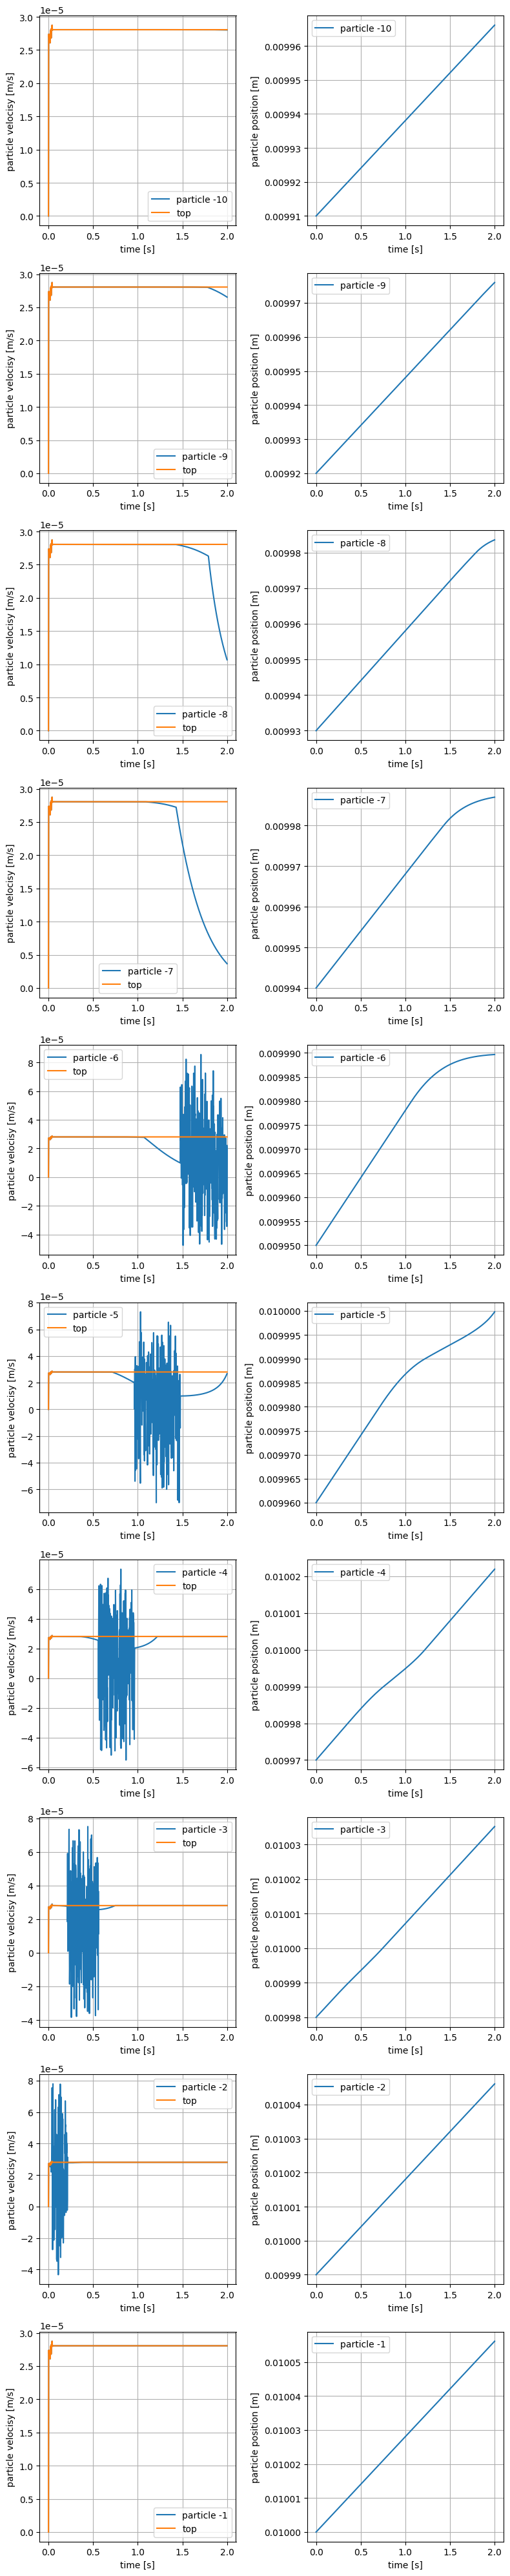

In [82]:
count = 10

fig, axes = plt.subplots(count,2, figsize=(4*2, count*4))
particles = np.arange(-count, 0)

for particle, vel_ax, pos_ax in zip(particles, axes[:,0], axes[:,1]):
    vel_ax.plot(
        time,
        v_p[particle,:],
        label=f'particle {particle}'
    )

    vel_ax.plot(
        time,
        v_p[0,:],
        label='top'
    )

    vel_ax.set_xlabel('time [s]')
    vel_ax.set_ylabel('particle velocisy [m/s]')
    vel_ax.legend()
    vel_ax.grid()
    
    pos_ax.plot(
        time,
        z_p[particle,:],
        label=f'particle {particle}'
    )

    # pos_ax.plot(
    #     time,
    #     z_p[0,:],
    #     label='top'
    # )

    pos_ax.set_xlabel('time [s]')
    pos_ax.set_ylabel('particle position [m]')
    pos_ax.legend()
    pos_ax.grid()
    
fig.tight_layout()

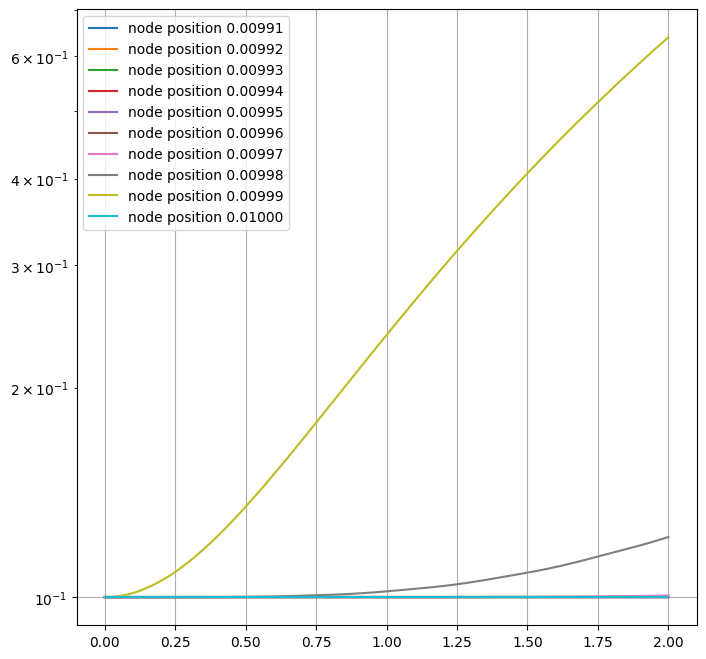

In [89]:
fig, ax = plt.subplots(1,1, figsize=(8,8))

nodes_cnt = 10
nodes = np.arange(-nodes_cnt, 0)

z_nodes = np.linspace(0, h_exit, N_E)

for node in nodes:
    ax.plot(
        time,
        phi[node,:],
        label=f'node position {z_nodes[node]:.5f}'
    )

ax.set_yscale('log')
pos_ax.set_xlabel('time [s]')
pos_ax.set_ylabel('particle concentration')
ax.legend()
ax.grid()

Upstream scheme

no boundary mask

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 101
N_E = 101
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 4)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
z_p [m] = [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018 0.0019
 0.002  0.0021 0.0022 0.0023 0.0024 0.0025 0.0026 0.0027 0.0028 0.0029
 0.003  0.0031 0.0032 0.0033 0.0034 0.0035 0.0036 0.0037 0.0038 0.0039
 0.004  0.0041 0.0042 0.0043 0.0044 0.0045 0.0046 0.0047 0.0048 0.0049
 0.005  0.0051 0.0052 0.0053 0.0054 0.0055 0.0056 0.0057 0.0058 0.0059
 0.006  0.0061 0.0062 0.0063 0.0064 0.0065 0.0066 0.0067 0.0068 0.0069
 0.007  0.0071 0.0072 0.0073 0.0074 0.0075 0.0076 0.0077 0.0078 0.0079
 0.008  0.0081 0.0082 0.0083 0.0084 0.0085 0.0086 0.0087 0.0088 0.0089
 0.009  0.0091 0.0092 0.0093 0.0094 0.0095 0.0096 0.0097 0.0098 0.0099
 0.01  ]
v_p [m/s] = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 

In [21]:
index_t = 522
t = numerical_results.t[index_t]
print(f'INTERIM, t= {t} s')
z_p, v_p, phi, q_phi = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

INTERIM, t= 2.09009009009009 s
z_p [m] = [5.86489821e-05 1.58648982e-04 2.58648982e-04 3.58648982e-04
 4.58648982e-04 5.58648982e-04 6.58648982e-04 7.58648982e-04
 8.58648982e-04 9.58648982e-04 1.05864898e-03 1.15864898e-03
 1.25864898e-03 1.35864898e-03 1.45864898e-03 1.55864898e-03
 1.65864898e-03 1.75864898e-03 1.85864898e-03 1.95864898e-03
 2.05864898e-03 2.15864898e-03 2.25864898e-03 2.35864898e-03
 2.45864898e-03 2.55864898e-03 2.65864898e-03 2.75864898e-03
 2.85864898e-03 2.95864898e-03 3.05864898e-03 3.15864898e-03
 3.25864898e-03 3.35864898e-03 3.45864898e-03 3.55864898e-03
 3.65864898e-03 3.75864898e-03 3.85864898e-03 3.95864898e-03
 4.05864898e-03 4.15864898e-03 4.25864898e-03 4.35864898e-03
 4.45864898e-03 4.55864898e-03 4.65864898e-03 4.75864898e-03
 4.85864898e-03 4.95864898e-03 5.05864898e-03 5.15864898e-03
 5.25864898e-03 5.35864898e-03 5.45864898e-03 5.55864898e-03
 5.65864898e-03 5.75864898e-03 5.85864898e-03 5.95864898e-03
 6.05864898e-03 6.15864898e-03 6.25864898e-0

Возможно, всему виной скорость предпредпоследней лагранжевой частицы - становится на порядок меньше остальных. НА САМОМ ДЕЛЕ ОНА НАЧИНАЕТ ОЧЕНЬ СИЛЬНО КОЛЕБАТЬСЯ

Возможно, надо мельчить сетку, так как от узла к узлу мы видим слишком резкий переход!

Faster, than with boundary mask. Result is the same. So something else becomes difficulter.

With boundary mask

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 101
N_E = 101
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 4)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
z_p [m] = [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018 0.0019
 0.002  0.0021 0.0022 0.0023 0.0024 0.0025 0.0026 0.0027 0.0028 0.0029
 0.003  0.0031 0.0032 0.0033 0.0034 0.0035 0.0036 0.0037 0.0038 0.0039
 0.004  0.0041 0.0042 0.0043 0.0044 0.0045 0.0046 0.0047 0.0048 0.0049
 0.005  0.0051 0.0052 0.0053 0.0054 0.0055 0.0056 0.0057 0.0058 0.0059
 0.006  0.0061 0.0062 0.0063 0.0064 0.0065 0.0066 0.0067 0.0068 0.0069
 0.007  0.0071 0.0072 0.0073 0.0074 0.0075 0.0076 0.0077 0.0078 0.0079
 0.008  0.0081 0.0082 0.0083 0.0084 0.0085 0.0086 0.0087 0.0088 0.0089
 0.009  0.0091 0.0092 0.0093 0.0094 0.0095 0.0096 0.0097 0.0098 0.0099
 0.01  ]
v_p [m/s] = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 101
N_E = 101
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 60)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

KeyboardInterrupt: 

TODO: проверить, может скорость счёта снижается из-за Лагранжевых частиц, падающих ниже границы? Может их стоит занулять?

In [6]:
index_t = 10
t = numerical_results.t[index_t]
print(f'INTERIM, t= {t} s')
z_p, v_p, phi, q_phi = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

INTERIM, t= 0.01001001001001001 s
z_p [m] = [2.80723700e-07 1.00280724e-04 2.00280724e-04 3.00280724e-04
 4.00280724e-04 5.00280724e-04 6.00280724e-04 7.00280724e-04
 8.00280724e-04 9.00280724e-04 1.00028072e-03 1.10028072e-03
 1.20028072e-03 1.30028072e-03 1.40028072e-03 1.50028072e-03
 1.60028072e-03 1.70028072e-03 1.80028072e-03 1.90028072e-03
 2.00028072e-03 2.10028072e-03 2.20028072e-03 2.30028072e-03
 2.40028072e-03 2.50028072e-03 2.60028072e-03 2.70028072e-03
 2.80028072e-03 2.90028072e-03 3.00028072e-03 3.10028072e-03
 3.20028072e-03 3.30028072e-03 3.40028072e-03 3.50028072e-03
 3.60028072e-03 3.70028072e-03 3.80028072e-03 3.90028072e-03
 4.00028072e-03 4.10028072e-03 4.20028072e-03 4.30028072e-03
 4.40028072e-03 4.50028072e-03 4.60028072e-03 4.70028072e-03
 4.80028072e-03 4.90028072e-03 5.00028072e-03 5.10028072e-03
 5.20028072e-03 5.30028072e-03 5.40028072e-03 5.50028072e-03
 5.60028072e-03 5.70028072e-03 5.80028072e-03 5.90028072e-03
 6.00028072e-03 6.10028072e-03 6.20028072

Downstream - unstable!

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 101
N_E = 101
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 1)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
z_p [m] = [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018 0.0019
 0.002  0.0021 0.0022 0.0023 0.0024 0.0025 0.0026 0.0027 0.0028 0.0029
 0.003  0.0031 0.0032 0.0033 0.0034 0.0035 0.0036 0.0037 0.0038 0.0039
 0.004  0.0041 0.0042 0.0043 0.0044 0.0045 0.0046 0.0047 0.0048 0.0049
 0.005  0.0051 0.0052 0.0053 0.0054 0.0055 0.0056 0.0057 0.0058 0.0059
 0.006  0.0061 0.0062 0.0063 0.0064 0.0065 0.0066 0.0067 0.0068 0.0069
 0.007  0.0071 0.0072 0.0073 0.0074 0.0075 0.0076 0.0077 0.0078 0.0079
 0.008  0.0081 0.0082 0.0083 0.0084 0.0085 0.0086 0.0087 0.0088 0.0089
 0.009  0.0091 0.0092 0.0093 0.0094 0.0095 0.0096 0.0097 0.0098 0.0099
 0.01  ]
v_p [m/s] = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 

Вывод: градиент концентрации возникает, однако он имеется только в тех 6 ячейках, где скорость явным образом умножается на коэффициент от 1 до 0! Возможно, причина ещё в том, что скорость изменения концентрации в верхнем узле постоянна.